In [64]:
# Load EDA handoff
import pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

with open('eda_handoff.pkl', 'rb') as _f:
    _h = pickle.load(_f)

df_units       = _h['df_units']
df_used_market = _h['df_used_market']
name_map       = _h['name_map']
lrfm           = _h.get('lrfm', None)

print(f'df_units: {df_units.shape}')
print(f'df_used_market: {df_used_market.shape}')
print(f'name_map entries: {len(name_map)}')
print(f'lrfm loaded: {lrfm is not None}')


df_units: (7539, 39)
df_used_market: (10239, 38)
name_map entries: 4234
lrfm loaded: True


### Feature Engineering — Segmentation Dimensions
Four features per RUC IMPORTADOR, aggregated from `df_units` (whole machines, FOB >= $10k):

| Feature | Definition | Captures |
|---|---|---|
| **Total_Spend** | Sum of FOB values | Scale / financial weight |
| **Product_Variety** | Distinct HS codes purchased | Portfolio breadth |
| **Years_Active** | Max year - min year | Relationship tenure |
| **Transaction_Count** | Row count (transactions) | Purchase frequency |

All features are standardised (z-score) before clustering to prevent spend dominating distance metrics.

In [66]:
from sklearn.preprocessing import StandardScaler

df_units['ANO'] = df_units['ANO'].astype(int)

FEATURES = ['Total_Spend', 'Product_Variety', 'Years_Active', 'Transaction_Count']

segmentation_data = df_units.groupby('RUC IMPORTADOR').agg({
    'US$ FOB':       'sum',
    'PARTIDA_CLEAN': 'nunique',
    'ANO':           [lambda x: x.max() - x.min(), 'count']
})
segmentation_data.columns = FEATURES

scaler          = StandardScaler()
scaled_features = scaler.fit_transform(segmentation_data)

print(f'Importers in segmentation matrix: {len(segmentation_data):,}')
display(segmentation_data.describe().round(1))


Importers in segmentation matrix: 1,444


,Total_Spend,Product_Variety,Years_Active,Transaction_Count
count,1444.0,1444.0,1444.0,1444.0
mean,323912.7,1.4,1.1,5.2
std,1775742.5,0.8,2.4,26.3
min,10000.0,1.0,0.0,1.0
25%,37046.0,1.0,0.0,1.0
50%,72160.0,1.0,0.0,1.0
75%,155463.8,2.0,1.0,3.0
max,43610122.8,8.0,11.0,717.0


### K-Means — Elbow Method & Baseline Fit
K-Means is fitted first to establish a baseline and to confirm that dominant
outlier importers distort centroids (motivating Stage 1 of the two-stage pipeline).
The elbow plot guides the choice of k for the baseline; k = 10 is used to match
the promoter's recommendation and to pre-label whales before formal Isolation Forest
detection in Module 1.

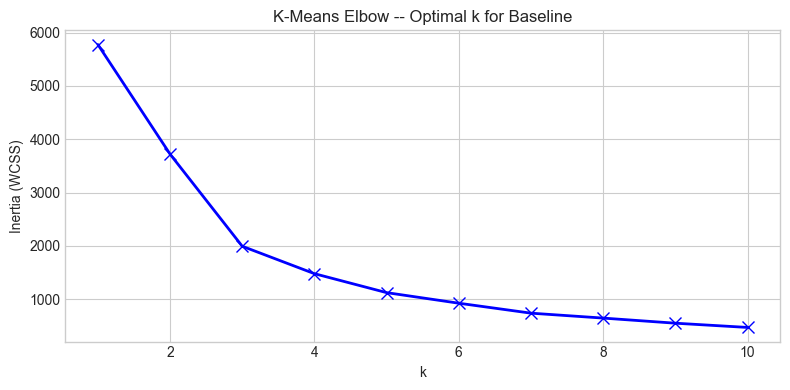

K-Means k=3 cluster sizes:
Cluster
0    1245
1     196
2       3
Name: count, dtype: int64


In [68]:
from sklearn.cluster import KMeans

# Elbow method
_inertia = []
_K = range(1, 11)
for _k in _K:
    _km = KMeans(n_clusters=_k, random_state=42, n_init=10)
    _inertia.append(_km.fit(scaled_features).inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(_K), _inertia, 'bx-', lw=2, markersize=8)
plt.xlabel('k'); plt.ylabel('Inertia (WCSS)')
plt.title('K-Means Elbow -- Optimal k for Baseline')
plt.tight_layout()
plt.savefig('3_k-means_elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Baseline k=3
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
segmentation_data['Cluster'] = km3.fit_predict(scaled_features)
print('K-Means k=3 cluster sizes:')
print(segmentation_data['Cluster'].value_counts().sort_index())


In [70]:
# K-Means k=10 (promoter recommendation / whale pre-labelling)
km10 = KMeans(n_clusters=10, random_state=42, n_init=10)
segmentation_data['Cluster_k10'] = km10.fit_predict(scaled_features)
print('K-Means k=10 cluster sizes:')
print(segmentation_data['Cluster_k10'].value_counts().sort_index())

# Profile by cluster
_prof_k10 = segmentation_data.groupby('Cluster_k10')[FEATURES].mean().round(0)
_prof_k10['N'] = segmentation_data['Cluster_k10'].value_counts().sort_index()
print('\nK-Means k=10 cluster profiles (mean):')
display(_prof_k10)


K-Means k=10 cluster sizes:
Cluster_k10
0      52
1    1025
2       1
3     118
4       1
5       5
6       1
7     183
8       7
9      51
Name: count, dtype: int64

K-Means k=10 cluster profiles (mean):


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,N
Cluster_k10,,,,,
0,1162096.0,4.0,5.0,18.0,52
1,80506.0,1.0,0.0,1.0,1025
2,43610123.0,4.0,11.0,717.0,1
3,403043.0,2.0,4.0,7.0,118
4,35773932.0,4.0,8.0,169.0,1
5,6465913.0,7.0,9.0,119.0,5
6,23790265.0,7.0,4.0,468.0,1
7,242543.0,2.0,1.0,4.0,183
8,7047317.0,3.0,10.0,134.0,7


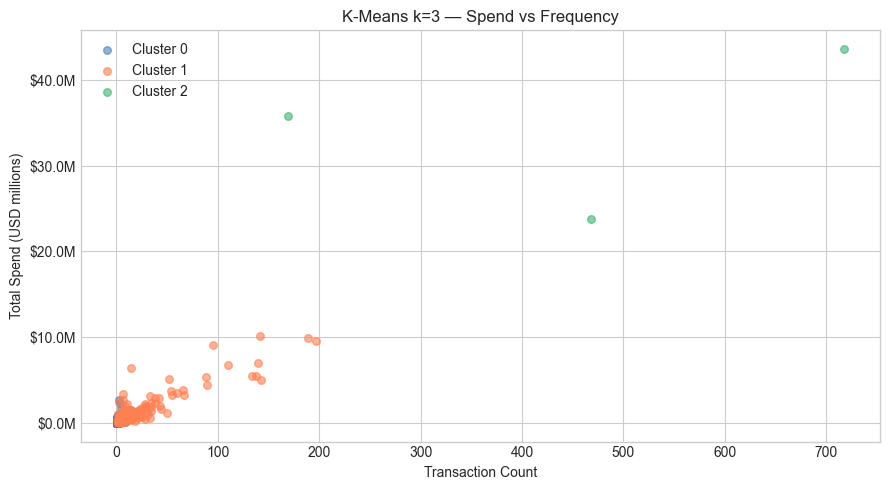

In [72]:
# Scatter: Total Spend vs Transaction Count, coloured by cluster
_colors = {0: 'steelblue', 1: 'coral', 2: 'mediumseagreen'}
fig, ax = plt.subplots(figsize=(9, 5))
for _cl, _grp in segmentation_data.groupby('Cluster'):
    ax.scatter(_grp['Transaction_Count'], _grp['Total_Spend'] / 1e6,
               label=f'Cluster {_cl}', alpha=0.6, s=30,
               color=_colors.get(_cl, 'grey'))
ax.set_xlabel('Transaction Count')
ax.set_ylabel('Total Spend (USD millions)')
ax.set_title('K-Means k=3 — Spend vs Frequency')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.1f}M'))
ax.legend(); plt.tight_layout(); plt.savefig('3_k-means_3_spend-frequency.png', dpi=150, bbox_inches='tight');plt.show()


In [74]:
# Identify which cluster contains the three CPtrucks client RUCs
CP_CLIENTS = ['20490425668', '20517931536', '20602250866']
_cp_rows = segmentation_data[segmentation_data.index.isin(CP_CLIENTS)]
print('CPtrucks clients in segmentation data:')
print(_cp_rows[['Total_Spend', 'Transaction_Count', 'Cluster']])

_target_cluster = _cp_rows['Cluster'].mode()[0] if not _cp_rows.empty else None
print(f'\nTarget cluster: {_target_cluster}')
print(f'Cluster size: {(segmentation_data["Cluster"] == _target_cluster).sum()}')


CPtrucks clients in segmentation data:
                Total_Spend  Transaction_Count  Cluster
RUC IMPORTADOR                                         
20490425668      5378581.24                 89        1
20517931536      9914193.52                189        1
20602250866      3270793.80                 67        1

Target cluster: 1
Cluster size: 196


In [76]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def cluster_metrics(X, labels, label=''):
    """Return Silhouette, Davies-Bouldin, Calinski-Harabasz for a clustering."""
    s  = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    if label:
        print(f'{label:40s}  Sil={s:.3f}  DBI={db:.3f}  CH={ch:.1f}')
    return s, db, ch

def compute_pwi(X, labels_list, k_list, top_n=3):
    """
    Peak Weight Index (PWI) - Wang & Xu (IOP Conf. Ser. Mater. Sci. Eng. 569, 2019).
    Combines Silhouette and Calinski-Harabasz with local peak weighting
    to select the optimal k without assuming a monotone quality curve.
    Returns a ranked DataFrame.
    """
    records = []
    for k, labels in zip(k_list, labels_list):
        s, db, ch = cluster_metrics(X, labels)
        records.append({'k': k, 'Silhouette': s, 'DBI': db, 'CH': ch})
    df_m = pd.DataFrame(records).set_index('k')
    # Normalise Silhouette and CH to [0,1]; invert DBI (lower is better)
    for col in ['Silhouette', 'CH']:
        rng = df_m[col].max() - df_m[col].min()
        df_m[col + '_n'] = (df_m[col] - df_m[col].min()) / (rng if rng else 1)
    df_m['DBI_n'] = 1 - (df_m['DBI'] - df_m['DBI'].min()) / \
                        ((df_m['DBI'].max() - df_m['DBI'].min()) or 1)
    df_m['PWI'] = df_m[['Silhouette_n', 'DBI_n', 'CH_n']].mean(axis=1)
    return df_m.sort_values('PWI', ascending=False)

# Baseline K-Means metrics (k=3 and k=10)
km_labels = [
    KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(scaled_features)
    for k in range(2, 11)
]
pwi_km = compute_pwi(scaled_features, km_labels, list(range(2, 11)))
print('K-Means PWI ranking:')
display(pwi_km[['Silhouette', 'DBI', 'CH', 'PWI']])


K-Means PWI ranking:


,Silhouette,DBI,CH,PWI
k,,,,
2,0.948716,0.410023,796.956053,0.666667
10,0.758122,0.614729,1802.905324,0.508700
9,0.757228,0.614329,1709.052279,0.476575
7,0.752562,0.750829,1638.084836,0.317438
8,0.757418,0.763146,1633.455145,0.311941
3,0.744721,0.669854,1368.731611,0.292002
6,0.737486,0.708685,1511.255485,0.291383
5,0.737666,0.764648,1492.215474,0.232753
4,0.736154,0.746603,1396.403305,0.215595


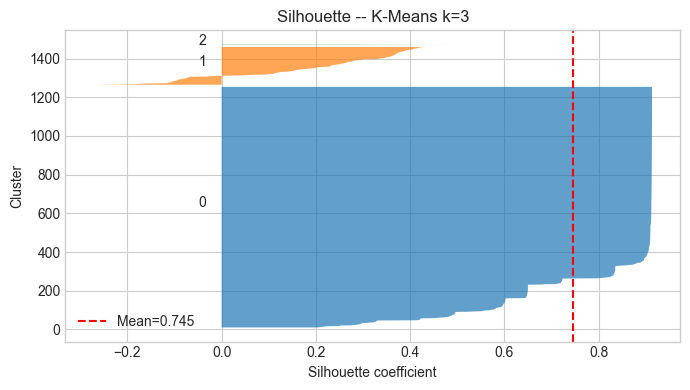

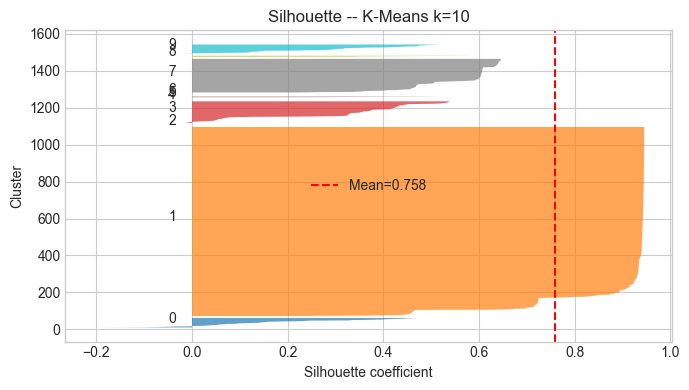

In [78]:
from sklearn.metrics import silhouette_samples

def plot_silhouette(X, labels, title=''):
    sil_vals = silhouette_samples(X, labels)
    k = len(set(labels))
    fig, ax = plt.subplots(figsize=(7, 4))
    y_lower = 10
    for i in range(k):
        vals = np.sort(sil_vals[labels == i])
        y_upper = y_lower + len(vals)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(vals), str(i))
        y_lower = y_upper + 10
    ax.axvline(x=sil_vals.mean(), color='red', linestyle='--', lw=1.5,
               label=f'Mean={sil_vals.mean():.3f}')
    ax.set_xlabel('Silhouette coefficient'); ax.set_ylabel('Cluster')
    ax.set_title(title or f'Silhouette Plot (k={k})')
    ax.legend(); plt.tight_layout(); plt.savefig('3_silhouette_plot.png', dpi=150, bbox_inches='tight'); plt.show()

plot_silhouette(scaled_features, segmentation_data['Cluster'].values,
                'Silhouette -- K-Means k=3')
plot_silhouette(scaled_features, segmentation_data['Cluster_k10'].values,
                'Silhouette -- K-Means k=10')


### Advanced Clustering Algorithms
K-Means assumes spherical, equally-sized clusters and is sensitive to outliers.
We now explore Gaussian Mixture Models (GMM) and Hierarchical Clustering to
assess whether a richer cluster structure exists and to build the narrative
justifying the two-stage pipeline in Module 1.

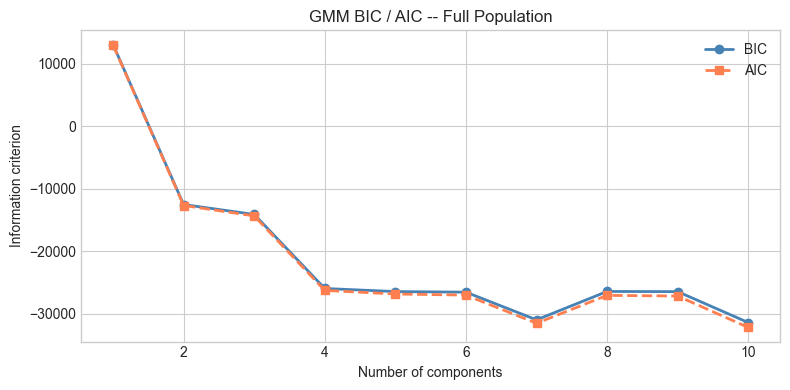

BIC-optimal k: 10
GMM k=10 (full)                           Sil=0.586  DBI=1.230  CH=714.6
GMM k=10 (Poisson noise)                  Sil=0.553  DBI=1.123  CH=752.7


In [80]:
from sklearn.mixture import GaussianMixture

_n_range = range(1, 11)
_bic = [GaussianMixture(n, covariance_type='full', random_state=42)
        .fit(scaled_features).bic(scaled_features) for n in _n_range]
_aic = [GaussianMixture(n, covariance_type='full', random_state=42)
        .fit(scaled_features).aic(scaled_features) for n in _n_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(_n_range), _bic, 'o-', lw=2, color='steelblue', label='BIC')
ax.plot(list(_n_range), _aic, 's--', lw=2, color='coral', label='AIC')
ax.set_xlabel('Number of components'); ax.set_ylabel('Information criterion')
ax.set_title('GMM BIC / AIC -- Full Population')
ax.legend(); plt.tight_layout(); plt.savefig('3_gmm-bic-aic-full.png', dpi=150, bbox_inches='tight'); plt.show()

# Fit GMM at BIC-optimal k
_best_k_gmm = list(_n_range)[np.argmin(_bic)]
print(f'BIC-optimal k: {_best_k_gmm}')

def run_gmm_and_plot(X, k, label=''):
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    lbl = gmm.fit_predict(X)
    s, db, ch = cluster_metrics(X, lbl, label or f'GMM k={k}')
    return gmm, lbl

gmm_full, labels_gmm_full = run_gmm_and_plot(scaled_features, _best_k_gmm,
                                              f'GMM k={_best_k_gmm} (full)')
segmentation_data['GMM_Cluster'] = labels_gmm_full

# Poisson noise stability test
rng = np.random.default_rng(42)
noisy = scaled_features + 0.05 * rng.standard_normal(scaled_features.shape)
_, labels_gmm_noisy = run_gmm_and_plot(noisy, _best_k_gmm,
                                        f'GMM k={_best_k_gmm} (Poisson noise)')


In [82]:
# Validate at k=7 (promoter recommendation)
gmm7, labels_gmm7 = run_gmm_and_plot(scaled_features, 7, 'GMM k=7 (full)')
segmentation_data['GMM_k7'] = labels_gmm7

print('GMM k=7 cluster sizes:')
print(pd.Series(labels_gmm7).value_counts().sort_index())

_prof_gmm7 = segmentation_data.groupby('GMM_k7')[FEATURES].mean().round(0)
_prof_gmm7['N'] = segmentation_data['GMM_k7'].value_counts().sort_index()
display(_prof_gmm7)


GMM k=7 (full)                            Sil=0.582  DBI=1.361  CH=742.9
GMM k=7 cluster sizes:
0    870
1     25
2      3
3    195
4    244
5     98
6      9
Name: count, dtype: int64


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,N
GMM_k7,,,,,
0,54610.0,1.0,0.0,1.0,870
1,3561244.0,3.0,7.0,48.0,25
2,34391440.0,5.0,8.0,451.0,3
3,198418.0,1.0,2.0,4.0,195
4,243851.0,2.0,2.0,5.0,244
5,753114.0,3.0,4.0,12.0,98
6,6224148.0,6.0,9.0,113.0,9


### Cluster Stability & Algorithm Comparison
Before selecting a final algorithm, we compare K-Means and GMM across multiple k values
and examine stability under noise. We also visualise how cluster profiles shift between
the original and noisy GMM solutions.

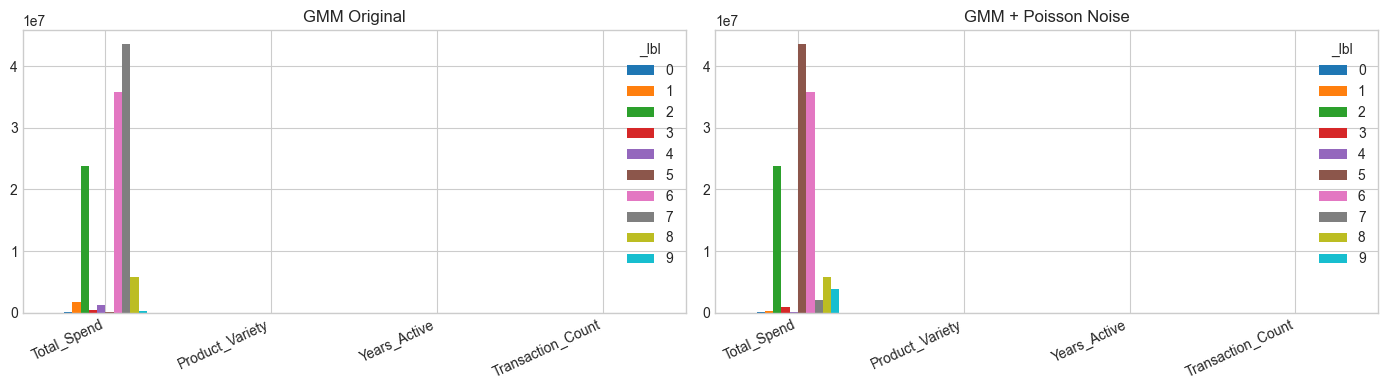

In [84]:
# Compare cluster profiles: original GMM vs noisy GMM
_k = _best_k_gmm
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, lbl, title in zip(axes,
                           [labels_gmm_full, labels_gmm_noisy],
                           ['GMM Original', 'GMM + Poisson Noise']):
    _d = segmentation_data.copy()
    _d['_lbl'] = lbl
    _p = _d.groupby('_lbl')[FEATURES].mean()
    _p.T.plot(kind='bar', ax=ax, legend=True)
    ax.set_title(title); ax.set_xticklabels(FEATURES, rotation=25, ha='right')
plt.tight_layout(); plt.savefig('3_gmm-poisson.png', dpi=150, bbox_inches='tight'); plt.show()


In [27]:
# GMM at k=3 and k=10 for apples-to-apples comparison with K-Means
_, labels_gmm3  = run_gmm_and_plot(scaled_features, 3,  'GMM k=3')
_, labels_gmm10 = run_gmm_and_plot(scaled_features, 10, 'GMM k=10')


GMM k=3                                   Sil=0.551  DBI=0.816  CH=877.0
GMM k=10                                  Sil=0.586  DBI=1.230  CH=714.6


### Full Metric Comparison — K-Means vs GMM
Silhouette, Davies-Bouldin Index (DBI), Calinski-Harabasz (CH), and the
Peak Weight Index (PWI) are computed for every (algorithm, k) combination.
PWI aggregates the three internal metrics into a single ranking, favouring
solutions that form local peaks rather than monotone trends.

Extended comparison table (Silhouette, DBI, CH, S_Dbw, PWI):


Silhouette           DBI            CH            S_Dbw           \
Algorithm        GMM KMeans    GMM KMeans    GMM  KMeans      GMM   KMeans   
k                                                                            
2              0.541  0.949  1.064  0.410  380.8   797.0   2.5418  19.2278   
3              0.551  0.745  0.816  0.670  877.0  1368.7  13.5201  13.5662   
4              0.566  0.736  1.149  0.747  820.9  1396.4  10.8780  11.0133   
5              0.583  0.738  1.282  0.765  820.7  1492.2   9.2240   8.9929   
6              0.579  0.737  1.804  0.709  749.5  1511.3   8.0579   3.9420   
7              0.582  0.753  1.361  0.751  742.9  1638.1   7.0474   3.5009   
8              0.579  0.757  1.334  0.763  702.2  1633.5   0.9494   3.1686   
9              0.566  0.757  1.784  0.614  647.9  1709.1   1.0512   0.7065   
10             0.586  0.758  1.230  0.615  714.6  1802.9   0.9874   0.5197   

              PWI          
Algorithm     GMM  KMeans  
k                          
2          0.2497  0.6667  
3          0.7407  0.2927  
4          0.7018  0.2155  
5          0.7827  0.2335  
6          0.5292  0.2909  
7          0.6964  0.3185  
8          0.6560  0.3119  
9          0.3714  0.4769  
10         0.7512  0.5086

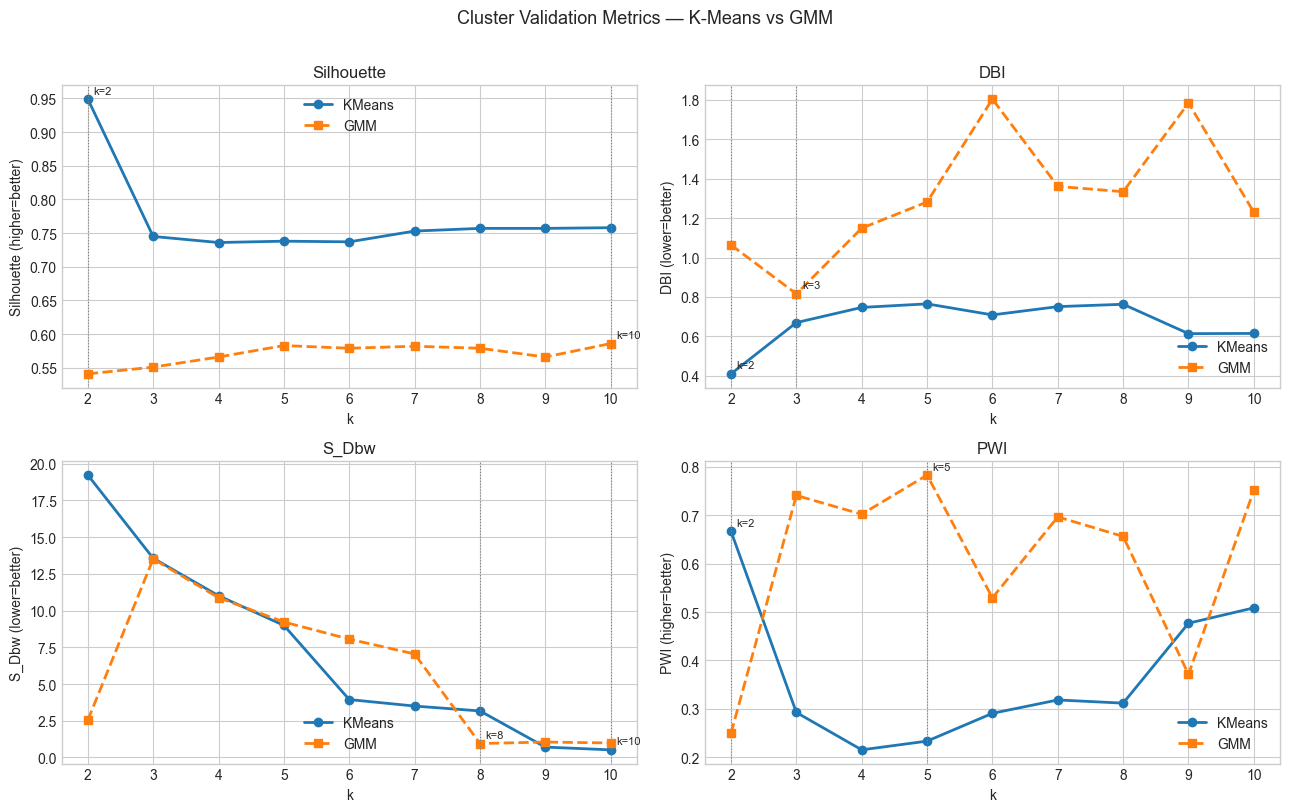

In [88]:
# ── S_Dbw and PWI added alongside Silhouette and DBI ───────────────────
# S_Dbw (Halkidi & Vazirgiannis, 2001): lower is better.
#   Scat(c)   = average ratio of intra-cluster variance to dataset variance.
#   Dens_bw(c)= average inter-centroid density relative to max cluster density.
#   S_Dbw     = Scat + Dens_bw
# PWI (Wang & Xu, 2019): higher is better.
#   Combines min-max normalised Silhouette, inverted DBI, and CH.
#   Computed separately per algorithm to avoid cross-algorithm scale contamination.

def sdbw(X, labels):
    """S_Dbw index — Halkidi & Vazirgiannis (2001). Lower is better."""
    X = np.array(X)
    ul = np.unique(labels)
    c  = len(ul)
    centroids    = np.array([X[labels == l].mean(axis=0) for l in ul])
    cluster_stds = np.array([X[labels == l].std(axis=0)  for l in ul])
    # Scat: average intra-cluster variance norm / dataset variance norm
    dv_norm = np.linalg.norm(X.var(axis=0))
    scat = (1 / c) * sum(
        np.linalg.norm(X[labels == l].var(axis=0)) / dv_norm for l in ul
    )
    # Bandwidth: average cluster stdev norm
    bw = (1 / c) * sum(np.linalg.norm(cluster_stds[i]) for i in range(c))
    # Dens_bw: inter-centroid density
    def _dens(pt, subset):
        return np.sum(np.linalg.norm(subset - pt, axis=1) <= bw)
    dens_bw = 0.0
    for i in range(c):
        Xi = X[labels == ul[i]]
        for j in range(c):
            if i == j:
                continue
            Xj   = X[labels == ul[j]]
            u_ij = (centroids[i] + centroids[j]) / 2
            d_u  = _dens(u_ij, np.vstack([Xi, Xj]))
            denom = max(_dens(centroids[i], Xi), _dens(centroids[j], Xj))
            dens_bw += d_u / denom if denom > 0 else 0.0
    dens_bw /= c * (c - 1)
    return scat + dens_bw


def pwi_from_df(sub):
    """PWI from a per-algorithm slice of df_comparison (Wang & Xu, 2019)."""
    def _norm(s, higher_better=True):
        rng = s.max() - s.min()
        n = (s - s.min()) / (rng if rng else 1)
        return n if higher_better else 1 - n
    return (_norm(sub['Silhouette']) +
            _norm(sub['DBI'], higher_better=False) +
            _norm(sub['CH'])) / 3


# ── Compute S_Dbw for every (algorithm, k) combination ──────────────────
_sdbw_records = []
for _k in range(2, 11):
    _lbl_km  = KMeans(n_clusters=_k, random_state=42, n_init=10).fit_predict(scaled_features)
    _lbl_gmm = GaussianMixture(_k, covariance_type='full', random_state=42).fit_predict(scaled_features)
    for _alg, _lbl in [('KMeans', _lbl_km), ('GMM', _lbl_gmm)]:
        _sdbw_records.append({'Algorithm': _alg, 'k': _k, 'S_Dbw': round(sdbw(scaled_features, _lbl), 4)})

df_sdbw = pd.DataFrame(_sdbw_records)
df_full = df_comparison.merge(df_sdbw, on=['Algorithm', 'k'])

# ── Compute PWI per algorithm ────────────────────────────────────────────
for _alg in ['KMeans', 'GMM']:
    _mask = df_full['Algorithm'] == _alg
    df_full.loc[_mask, 'PWI'] = pwi_from_df(df_full[_mask]).values

df_full['PWI'] = df_full['PWI'].round(4)
print('Extended comparison table (Silhouette, DBI, CH, S_Dbw, PWI):')
display(df_full.pivot(index='k', columns='Algorithm', values=['Silhouette', 'DBI', 'CH', 'S_Dbw', 'PWI']))

# ── 2×2 plot: Silhouette | DBI | S_Dbw | PWI ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
metrics_cfg = [
    ('Silhouette', 'Silhouette (higher=better)', 'max'),
    ('DBI',        'DBI (lower=better)',          'min'),
    ('S_Dbw',      'S_Dbw (lower=better)',        'min'),
    ('PWI',        'PWI (higher=better)',          'max'),
]
for ax, (metric, ylabel, best) in zip(axes.flat, metrics_cfg):
    for alg, ls in [('KMeans', '-o'), ('GMM', '--s')]:
        sub = df_full[df_full['Algorithm'] == alg].sort_values('k')
        ax.plot(sub['k'], sub[metric], ls, lw=2, label=alg)
        # Mark optimum
        opt_k = sub.loc[sub[metric].idxmax() if best == 'max' else sub[metric].idxmin(), 'k']
        opt_v = sub.loc[sub['k'] == opt_k, metric].values[0]
        ax.axvline(opt_k, color='gray', lw=0.8, linestyle=':')
        ax.annotate(f'k={opt_k}', xy=(opt_k, opt_v), xytext=(4, 4),
                    textcoords='offset points', fontsize=8)
    ax.set_xlabel('k'); ax.set_ylabel(ylabel)
    ax.set_title(metric); ax.set_xticks(range(2, 11)); ax.legend()

plt.suptitle('Cluster Validation Metrics — K-Means vs GMM', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('3_metrics-comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [90]:
# Focus on corporate importers (transaction_count >= 3) for fine-grained segmentation
_corp_mask = segmentation_data['Transaction_Count'] >= 3
_X_corp = scaled_features[_corp_mask]
_seg_corp = segmentation_data[_corp_mask].copy()

print(f'Corporate importers: {_corp_mask.sum():,} / {len(segmentation_data):,}')

_, _lbl_corp10 = run_gmm_and_plot(_X_corp, 10, 'GMM k=10 (corporate)')
_, _lbl_corp7  = run_gmm_and_plot(_X_corp,  7, 'GMM k=7 (corporate)')

_seg_corp['GMM_corp10'] = _lbl_corp10
_seg_corp['GMM_corp7']  = _lbl_corp7

_prof_corp = _seg_corp.groupby('GMM_corp7')[FEATURES].mean().round(0)
_prof_corp['N'] = _seg_corp['GMM_corp7'].value_counts().sort_index()
print('Corporate GMM k=7 profiles:')
display(_prof_corp)


Corporate importers: 413 / 1,444
GMM k=10 (corporate)                      Sil=0.245  DBI=2.069  CH=161.9
GMM k=7 (corporate)                       Sil=0.244  DBI=1.974  CH=184.1
Corporate GMM k=7 profiles:


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,N
GMM_corp7,,,,,
0,356901.0,3.0,4.0,7.0,49
1,43610123.0,4.0,11.0,717.0,1
2,29782099.0,6.0,6.0,318.0,2
3,5115929.0,4.0,8.0,85.0,24
4,217496.0,1.0,2.0,4.0,127
5,406992.0,2.0,3.0,7.0,167
6,1314049.0,3.0,5.0,17.0,43


In [92]:
from sklearn.ensemble import IsolationForest

# Stage 1: Isolation Forest — detect whale importers
# Run this before HC so the dendrogram shows core-population structure,
# not outlier-dominated merges.
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
iso_labels = iso.fit_predict(scaled_features)   # -1 = whale, 1 = core
whale_mask = iso_labels == -1
core_mask  = iso_labels ==  1

segmentation_data['IsWhale'] = whale_mask
df_core  = segmentation_data[core_mask].copy()
df_whale = segmentation_data[whale_mask].copy()
X_core   = scaled_features[core_mask]

print('Stage 1 -- Isolation Forest (contamination=0.05, n_estimators=300):')
print(f'  Core importers : {core_mask.sum():,}')
print(f'  Whale importers: {whale_mask.sum():,}')
print()
print('Whale pool (top 10 by spend):')
_whale_view = df_whale[['Total_Spend', 'Transaction_Count', 'Years_Active']].copy()
_whale_view.index = [name_map.get(r, r) for r in df_whale.index]
display(_whale_view.sort_values('Total_Spend', ascending=False).head(10))


Stage 1 -- Isolation Forest (contamination=0.05, n_estimators=300):
  Core importers : 1,371
  Whale importers: 73

Whale pool (top 10 by spend):


,Total_Spend,Transaction_Count,Years_Active
MC MACHINERY & ELECTRONIC S.A.C,43610122.85,717,11
FERREYROS SOCIEDAD AN?NIMA,35773932.42,169,8
Ley 29733 Protección de datos personales,23790265.06,468,4
GH EQUIPMENT E.I.R.L.,10166986.68,142,11
KARLA EQUIPMENT S.A.C.,9914193.52,189,11
DESERT LOGISTIC SERVICES S.A.C.,9606640.38,197,11
MATERIALES Y SERVICIOS GENERALES FABRI E.I.R.L.,9072490.44,95,5
ECA BUSINESS E.I.R.L.,7017716.87,140,6
DAMICON BUSINESS S.A.C.,6748279.94,110,9
SANDVIK DEL PERU S A,6392561.98,15,8


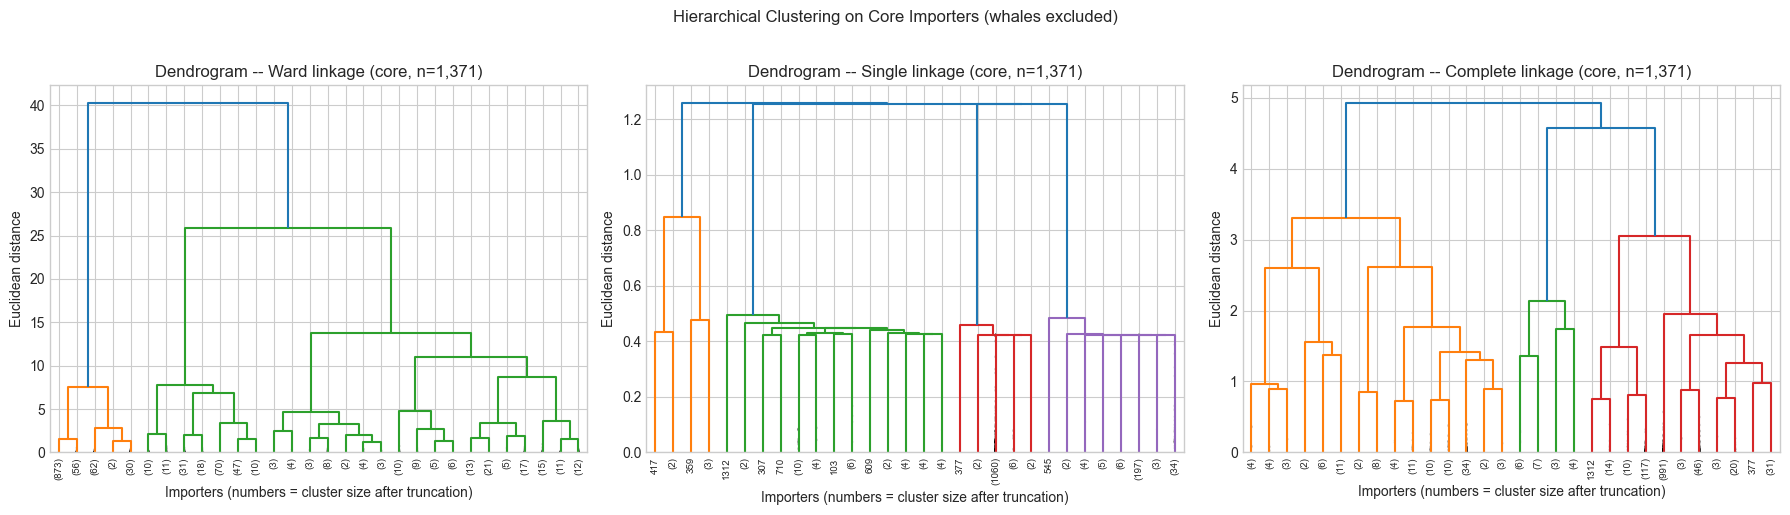

Note: numbers on the x-axis are the SIZE of each collapsed subtree,
not importer IDs. The full tree has 1371 leaves.


In [94]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Run HC on the core population (whales already removed)
# Ward linkage is best for compact, well-separated clusters.
# Single and Complete are shown for comparison.
_linkages = {
    'Ward':     linkage(X_core, method='ward'),
    'Single':   linkage(X_core, method='single'),
    'Complete': linkage(X_core, method='complete'),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (method, Z) in zip(axes, _linkages.items()):
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
               leaf_rotation=90, leaf_font_size=7, show_contracted=True)
    ax.set_title(f'Dendrogram -- {method} linkage (core, n={core_mask.sum():,})')
    ax.set_xlabel('Importers (numbers = cluster size after truncation)')
    ax.set_ylabel('Euclidean distance')
plt.suptitle('Hierarchical Clustering on Core Importers (whales excluded)',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.savefig('3_hcs.png', dpi=150, bbox_inches='tight'); plt.show()

print('Note: numbers on the x-axis are the SIZE of each collapsed subtree,')
print('not importer IDs. The full tree has', len(X_core), 'leaves.')


In [96]:
# Cut Ward dendrogram at k=4
_Z_ward = _linkages['Ward']
_hc_labels = fcluster(_Z_ward, t=4, criterion='maxclust') - 1  # 0-indexed
df_core['HC_Cluster'] = _hc_labels

cluster_metrics(X_core, _hc_labels, 'Hierarchical Ward k=4 (core)')

print('HC k=4 cluster sizes (core importers only):')
print(pd.Series(_hc_labels).value_counts().sort_index())

_prof_hc = df_core.groupby('HC_Cluster')[FEATURES].mean().round(0)
_prof_hc['N'] = df_core['HC_Cluster'].value_counts().sort_index()
print('\nHC k=4 cluster profiles:')
display(_prof_hc)


Hierarchical Ward k=4 (core)              Sil=0.788  DBI=0.738  CH=2113.9
HC k=4 cluster sizes (core importers only):
0    1023
1     197
2      27
3     124
Name: count, dtype: int64

HC k=4 cluster profiles:


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,N
HC_Cluster,,,,,
0,77799.0,1.0,0.0,1.0,1023
1,215241.0,2.0,1.0,4.0,197
2,447822.0,3.0,6.0,9.0,27
3,365178.0,2.0,6.0,6.0,124


### Feature Distributions Across Hierarchical Clusters
Box plots show how each feature distributes within each HC cluster (core population only),
confirming whether the algorithm produces interpretable, well-separated segments.

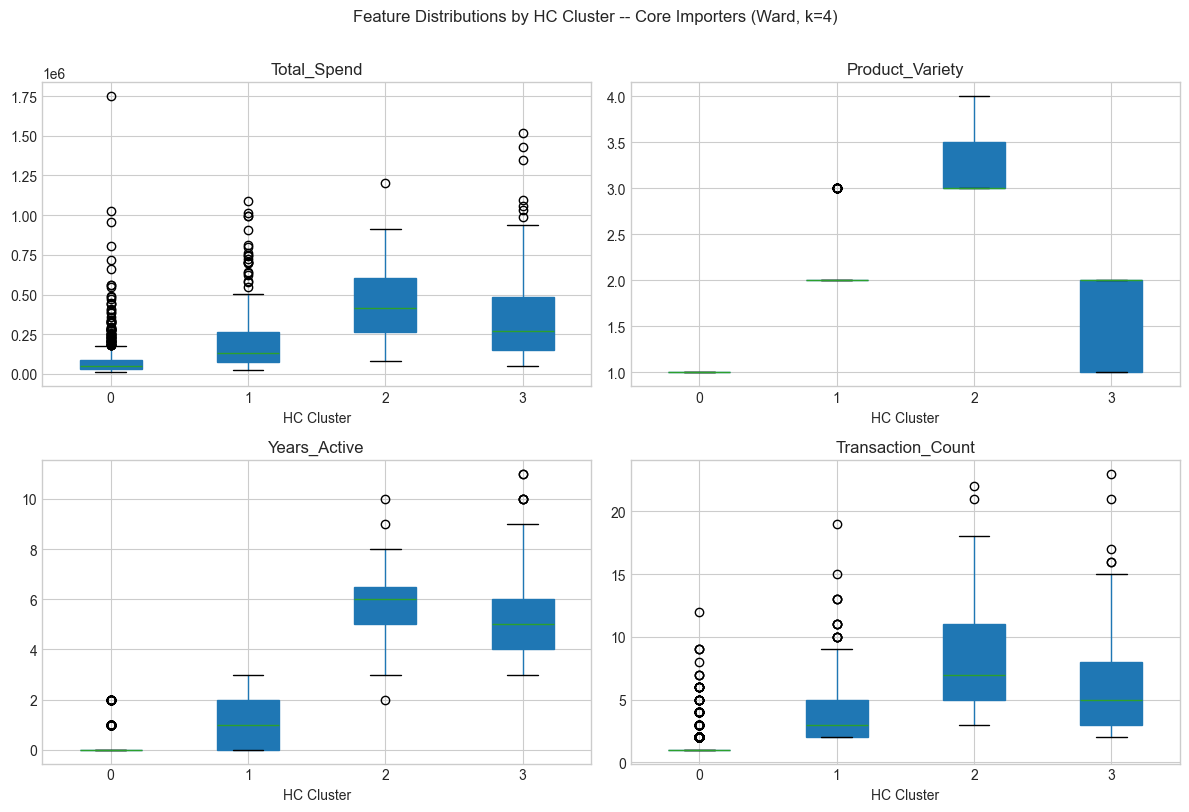

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, FEATURES):
    df_core.boxplot(column=feat, by='HC_Cluster', ax=ax,
                    patch_artist=True, notch=False)
    ax.set_title(feat); ax.set_xlabel('HC Cluster')
    plt.sca(ax)
plt.suptitle('Feature Distributions by HC Cluster -- Core Importers (Ward, k=4)', y=1.01)
plt.tight_layout(); plt.savefig('3_feature_by_hc_cluster.png', dpi=150, bbox_inches='tight'); plt.show()


In [100]:
# Summary: compare all final single-algorithm solutions side-by-side
# Note: K-Means and GMM metrics use scaled_features (full population);
# HC metric uses X_core (core only). The whale effect explains the gap.
print('=== Final Algorithm Comparison (full population) ===')
solutions_full = [
    ('K-Means k=3',   segmentation_data['Cluster'].values),
    ('K-Means k=10',  segmentation_data['Cluster_k10'].values),
    (f'GMM k={_best_k_gmm}', segmentation_data['GMM_Cluster'].values),
    ('GMM k=7',        segmentation_data['GMM_k7'].values),
]
for name, lbl in solutions_full:
    cluster_metrics(scaled_features, lbl, name)

print('\n=== Hierarchical Ward k=4 (core population only) ===')
cluster_metrics(X_core, _hc_labels, 'HC Ward k=4 (core)')


=== Final Algorithm Comparison (full population) ===
K-Means k=3                               Sil=0.745  DBI=0.670  CH=1368.7
K-Means k=10                              Sil=0.758  DBI=0.615  CH=1802.9
GMM k=10                                  Sil=0.586  DBI=1.230  CH=714.6
GMM k=7                                   Sil=0.582  DBI=1.361  CH=742.9

=== Hierarchical Ward k=4 (core population only) ===
HC Ward k=4 (core)                        Sil=0.788  DBI=0.738  CH=2113.9


(0.7879907394893102, 0.7379335343868726, 2113.8734044431703)

### Module 1 — Two-Stage Clustering Pipeline
**Stage 1 -- Whale Separation (Isolation Forest)**
Already computed above. Isolation Forest (Liu et al., 2008) flagged
73 whale importers and isolated 1,371 core importers.

**Stage 2 -- Refined GMM on Core Population**
GMM (full covariance) is fitted on `X_core`. BIC selects the optimal k from {3,...,7},
producing clean, interpretable segments without outlier leverage.

Stage 2 -- BIC-optimal k on core: 7
Stage 2 GMM k=7 (core)                    Sil=0.637  DBI=1.081  CH=663.4


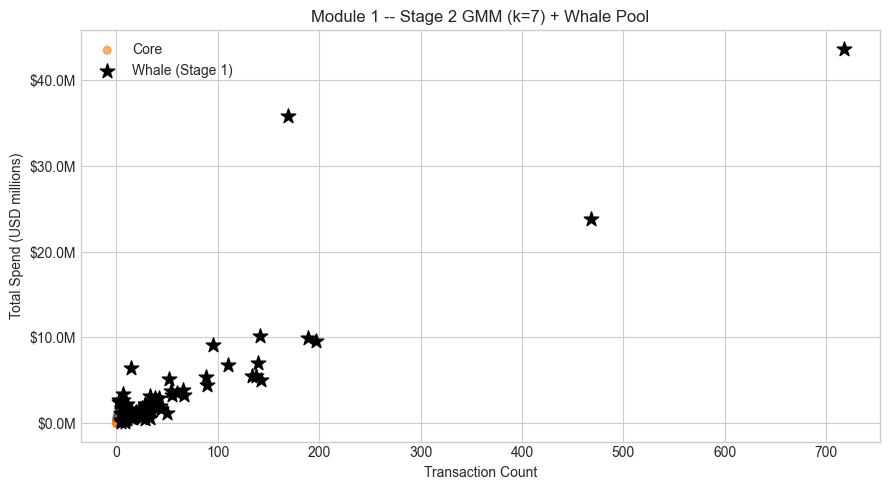

In [102]:
from sklearn.mixture import GaussianMixture

# Stage 2: GMM on core population, BIC scan over k=3..7
_bic_core = [
    GaussianMixture(k, covariance_type='full', random_state=42)
    .fit(X_core).bic(X_core)
    for k in range(3, 8)
]
_best_k_core = list(range(3, 8))[np.argmin(_bic_core)]
print(f'Stage 2 -- BIC-optimal k on core: {_best_k_core}')

gmm_core = GaussianMixture(_best_k_core, covariance_type='full', random_state=42)
df_core['Stage2_Cluster'] = gmm_core.fit_predict(X_core)

cluster_metrics(X_core, df_core['Stage2_Cluster'].values,
                f'Stage 2 GMM k={_best_k_core} (core)')

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_core['Transaction_Count'], df_core['Total_Spend'] / 1e6,
           c=df_core['Stage2_Cluster'], cmap='tab10', alpha=0.6, s=30,
           label='Core')
ax.scatter(df_whale['Transaction_Count'], df_whale['Total_Spend'] / 1e6,
           marker='*', s=120, color='black', label='Whale (Stage 1)')
ax.set_xlabel('Transaction Count')
ax.set_ylabel('Total Spend (USD millions)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f'${v:.1f}M'))
ax.set_title(f'Module 1 -- Stage 2 GMM (k={_best_k_core}) + Whale Pool')
ax.legend(); plt.tight_layout(); plt.savefig('3_module1-stage2gmm-k7-whale.png', dpi=150, bbox_inches='tight'); plt.show()


=== Stage 2 GMM Cluster Profiles (mean) ===


,Total_Spend,Product_Variety,Years_Active,Transaction_Count,N
Stage2_Cluster,,,,,
0,428493.0,2.0,4.0,7.0,126
1,54610.0,1.0,0.0,1.0,870
2,198546.0,2.0,11.0,4.0,2
3,226372.0,1.0,2.0,4.0,201
4,385722.0,3.0,3.0,8.0,41
5,402240.0,4.0,4.0,7.0,7
6,107538.0,2.0,1.0,3.0,124



=== Whale Pool (Stage 1 outliers) ===


,Total_Spend,Product_Variety,Years_Active,Transaction_Count
MC MACHINERY & ELECTRONIC S.A.C,43610122.85,4,11,717
FERREYROS SOCIEDAD AN?NIMA,35773932.42,4,8,169
Ley 29733 Protección de datos personales,23790265.06,7,4,468
GH EQUIPMENT E.I.R.L.,10166986.68,4,11,142
KARLA EQUIPMENT S.A.C.,9914193.52,8,11,189
DESERT LOGISTIC SERVICES S.A.C.,9606640.38,4,11,197
MATERIALES Y SERVICIOS GENERALES FABRI E.I.R.L.,9072490.44,3,5,95
ECA BUSINESS E.I.R.L.,7017716.87,6,6,140
DAMICON BUSINESS S.A.C.,6748279.94,7,9,110
SANDVIK DEL PERU S A,6392561.98,2,8,15


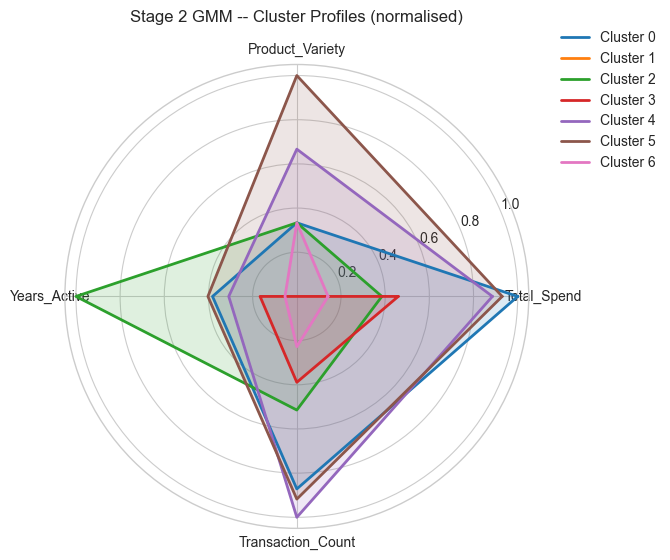

In [104]:
from sklearn.preprocessing import MinMaxScaler

# Stage 2 profiles table
_prof = df_core.groupby('Stage2_Cluster')[FEATURES].mean().round(0)
_prof['N'] = df_core['Stage2_Cluster'].value_counts().sort_index()
print('=== Stage 2 GMM Cluster Profiles (mean) ===')
display(_prof)

# Whale summary
print('\n=== Whale Pool (Stage 1 outliers) ===')
_whale_view = df_whale[FEATURES].copy()
_whale_view.index = [name_map.get(r, r) for r in df_whale.index]
display(_whale_view.sort_values('Total_Spend', ascending=False).head(20))

# CPtrucks clients
_cp = df_core[df_core.index.isin(CP_CLIENTS)]
if not _cp.empty:
    print('\n=== CPtrucks Clients ===')
    _cp_view = _cp[FEATURES + ['Stage2_Cluster']].copy()
    _cp_view.index = [name_map.get(r, r) for r in _cp.index]
    display(_cp_view)

# Radar chart for Stage 2 profiles
_n_feat = len(FEATURES)
_angles = np.linspace(0, 2 * np.pi, _n_feat, endpoint=False).tolist()
_angles += _angles[:1]

_mms = MinMaxScaler()
_prof_n = pd.DataFrame(
    _mms.fit_transform(df_core.groupby('Stage2_Cluster')[FEATURES].mean()),
    columns=FEATURES,
    index=range(df_core['Stage2_Cluster'].nunique())
)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
_colors_radar = plt.cm.tab10.colors
for _cl in _prof_n.index:
    vals = _prof_n.loc[_cl].tolist() + [_prof_n.loc[_cl, FEATURES[0]]]
    ax.plot(_angles, vals, lw=2, label=f'Cluster {_cl}',
            color=_colors_radar[_cl % 10])
    ax.fill(_angles, vals, alpha=0.15, color=_colors_radar[_cl % 10])
ax.set_xticks(_angles[:-1])
ax.set_xticklabels(FEATURES, fontsize=10)
ax.set_title('Stage 2 GMM -- Cluster Profiles (normalised)', pad=15)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.show()


In [106]:
# ── Validation Metrics — Stage 2 GMM on Core Population (k=3..7) ────────
# Mirrors the full-population table in Cell 18 but restricted to X_core
# (1,371 importers after whale removal). S_Dbw and PWI reuse the functions
# defined in Cell 18. BIC-selected k is highlighted.

_stage2_records = []
for _k in range(3, 8):
    _lbl = GaussianMixture(_k, covariance_type='full', random_state=42).fit_predict(X_core)
    _s, _db, _ch = cluster_metrics(X_core, _lbl)
    _sd = sdbw(X_core, _lbl)
    _stage2_records.append({
        'k':          _k,
        'Silhouette': round(_s,  4),
        'DBI':        round(_db, 4),
        'CH':         round(_ch, 2),
        'S_Dbw':      round(_sd, 4),
    })

df_stage2_metrics = pd.DataFrame(_stage2_records).set_index('k')

# PWI: normalise within this dataset (higher = better)
def _norm(s, higher_better=True):
    rng = s.max() - s.min()
    n = (s - s.min()) / (rng if rng else 1)
    return n if higher_better else 1 - n

df_stage2_metrics['PWI'] = (
    _norm(df_stage2_metrics['Silhouette']) +
    _norm(df_stage2_metrics['DBI'], higher_better=False) +
    _norm(df_stage2_metrics['CH'])
) / 3
df_stage2_metrics['PWI'] = df_stage2_metrics['PWI'].round(4)

# Highlight the BIC-selected k
def _highlight_bic(row):
    return ['font-weight: bold; background-color: #d4edda' if row.name == _best_k_core
            else '' for _ in row]

print(f'Stage 2 GMM — Validation Metrics on Core Population (n=1,371)')
print(f'BIC-selected k = {_best_k_core}  (highlighted)')
print(f'  Silhouette : higher = better')
print(f'  DBI        : lower  = better')
print(f'  CH         : higher = better')
print(f'  S_Dbw      : lower  = better  (Halkidi & Vazirgiannis, 2001)')
print(f'  PWI        : higher = better  (Wang & Xu, 2019)')
print()
display(df_stage2_metrics.style.apply(_highlight_bic, axis=1))


Stage 2 GMM — Validation Metrics on Core Population (n=1,371)
BIC-selected k = 7  (highlighted)
  Silhouette : higher = better
  DBI        : lower  = better
  CH         : higher = better
  S_Dbw      : lower  = better  (Halkidi & Vazirgiannis, 2001)
  PWI        : higher = better  (Wang & Xu, 2019)



,Silhouette,DBI,CH,S_Dbw,PWI
k,,,,,
3,0.621500,2.689600,542.650000,2.350900,0.185600
4,0.618700,1.520400,684.570000,1.842600,0.590800
5,0.620100,3.011800,522.660000,2.226400,0.068500
6,0.618800,1.182700,498.780000,1.201400,0.317600
7,0.636900,1.080900,663.450000,0.831900,0.962100


In [108]:
# Save clustering outputs for mba_phase_four.ipynb
import pickle, os

_handoff = {
    # Pass-through from EDA
    'df_units':          df_units,
    'df_used_market':    df_used_market,
    'name_map':          name_map,
    'lrfm':              lrfm,
    # Built in this notebook
    'segmentation_data': segmentation_data,
    'scaled_features':   scaled_features,
    'scaler':            scaler,
    'FEATURES':          FEATURES,
    # Two-stage output (Module 1)
    'df_core':           df_core,
    'df_whale':          df_whale,
    'gmm_core':          gmm_core,
    'best_k_core':       _best_k_core,
}

with open('clustering_handoff.pkl', 'wb') as _f:
    pickle.dump(_handoff, _f)

print('clustering_handoff.pkl saved.')
print(f'  segmentation_data shape : {segmentation_data.shape}')
print(f'  df_core shape           : {df_core.shape}')
print(f'  df_whale shape          : {df_whale.shape}')
print(f'  Stage 2 k               : {_best_k_core}')
print(f'  lrfm included           : {lrfm is not None}')


clustering_handoff.pkl saved.
  segmentation_data shape : (1444, 9)
  df_core shape           : (1371, 11)
  df_whale shape          : (73, 9)
  Stage 2 k               : 7
  lrfm included           : True
